# Piloto Experimental — Aplicación de la Inteligencia Artificial en la Innovación Educativa: Modelos predictivos y de clasificación para la mejora del aprendizaje.

**Trabajo Fin de Máster — Universidad Internacional de La Rioja (UNIR)**  

Autores: Gloria Lida Alzate Suárez · Miguel Fernando Morales Valderrama  
Director: Víctor Daniel Diaz Suarez

---

Este cuaderno orquesta las cinco fases (F1–F5) del piloto experimental descrito en el Capítulo 3 del TFM, sobre el *Open University Learning Analytics Dataset* (OULAD). Cada sección corresponde a un objetivo específico (OE) y a un módulo del pipeline.

**Reproducibilidad:** todas las semillas aleatorias están fijadas en `random_state = 42`. El conjunto de datos OULAD se obtiene de fuentes públicas (https://analyse.kmi.open.ac.uk/) y los archivos `.csv` se ubican en `./data/oulad/`.

---

## 0. Configuración del entorno

In [1]:
# Instalamos las librerías básicas de ciencia de datos y visualización (descomentar si es necesario instalarlas).
# %pip install numpy pandas matplotlib seaborn
import sys
# path sirve para manejar rutas de archivos y carpetas como si fueran objetos, en lugar de tratarlas como simples textos (strings).
from pathlib import Path 

# Aseguramos que los módulos "src/" sean accesibles desde el notebook
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ignoramos las advertencias de UserWarning y FutureWarning para mantener la salida limpia.
warnings.filterwarnings('ignore', category=UserWarning)
# Las advertencias de FutureWarning indican que ciertas características o comportamientos de las bibliotecas
# pueden cambiar en el futuro, lo que puede afectar la compatibilidad del código. 
# Al ignorarlas, evitamos que estas advertencias llenen la salida,
# aunque es importante revisar periódicamente el código para asegurarse de que sigue siendo compatible
# con las versiones futuras de las bibliotecas.
warnings.filterwarnings('ignore', category=FutureWarning)

# Configuramos el estilo de los gráficos con Seaborn y ajustamos la resolución de las figuras.
sns.set_style('whitegrid')
sns.set_palette('Blues_r')
plt.rcParams['figure.dpi'] = 110

# Definimos las rutas para los datos y los resultados, asegurándonos de que el directorio de resultados exista.
DATA_PATH = PROJECT_ROOT / 'data' / 'oulad'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Working directory:', PROJECT_ROOT)
print('OULAD path       :', DATA_PATH)
print('Results path     :', RESULTS_DIR)

Working directory: d:\WORK_SPACE\VSCode\TFM
OULAD path       : d:\WORK_SPACE\VSCode\TFM\data\oulad
Results path     : d:\WORK_SPACE\VSCode\TFM\results


### 0.1 Descarga del OULAD (opcional)

Si no dispones aún del dataset, descomenta el bloque siguiente para descargarlo desde Kaggle mediante la CLI oficial `kaggle` o bien descárgalo manualmente desde la web de OULAD.

In [2]:
#import sys
#!{sys.executable} -m pip install --upgrade kagglehub

In [3]:
#!{sys.executable} -m pip install --upgrade --force-reinstall --no-cache-dir kagglehub

In [4]:
#import kagglehub
#print(kagglehub.__version__)               # debería ser 0.3.x o superior
#print("dataset_download" in dir(kagglehub)) # ahora debe ser True

In [5]:
# Descargamos el dataset OULAD desde Kaggle usando la librería kagglehub, 
# que facilita la descarga de datasets públicos de Kaggle.
#%pip install kagglehub
import kagglehub
import shutil
from pathlib import Path

# Usar la DATA_PATH definida al inicio del notebook
# kagglehub descarga a una ubicación temporal, así que copiamos los archivos

print("Descargando OULAD desde Kaggle (esto tarda 3-10 minutos)...")
temp_path = kagglehub.dataset_download("anlgrbz/student-demographics-online-education-dataoulad")

# Crear la carpeta de destino si no existe
DATA_PATH.mkdir(parents=True, exist_ok=True)

# Copiar todos los CSV a la carpeta del proyecto
print(f"\nCopiando archivos a {DATA_PATH}...")
copied_files = []
for csv_file in Path(temp_path).glob('*.csv'):
    dest_file = DATA_PATH / csv_file.name
    shutil.copy2(csv_file, dest_file)
    print(f"  ✓ {csv_file.name}")
    copied_files.append(csv_file.name)

print(f"\n✓ OULAD descargado y guairdado exitosamente")
print(f"  Ubicación: {DATA_PATH}")
print(f"  Total archivos: {len(copied_files)} CSV")

Descargando OULAD desde Kaggle (esto tarda 3-10 minutos)...

Copiando archivos a d:\WORK_SPACE\VSCode\TFM\data\oulad...
  ✓ assessments.csv
  ✓ courses.csv
  ✓ studentAssessment.csv
  ✓ studentInfo.csv
  ✓ studentRegistration.csv
  ✓ studentVle.csv
  ✓ vle.csv

✓ OULAD descargado y guairdado exitosamente
  Ubicación: d:\WORK_SPACE\VSCode\TFM\data\oulad
  Total archivos: 7 CSV


In [6]:
import kagglehub
print(kagglehub.__file__)
print(kagglehub.__version__ if hasattr(kagglehub, "__version__") else "sin __version__")
print(dir(kagglehub))

c:\Users\mfmoralesv\AppData\Local\Programs\Python\Python311\Lib\site-packages\kagglehub\__init__.py
1.0.1
['KaggleDatasetAdapter', 'PolarsFrameType', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'auth', 'cache', 'clients', 'colab_cache_resolver', 'competition', 'competition_download', 'config', 'dataset_download', 'dataset_load', 'dataset_upload', 'datasets', 'datasets_enums', 'datasets_helpers', 'enum', 'env', 'exceptions', 'gcs_upload', 'get_package_asset_path', 'handle', 'http_resolver', 'integrity', 'kaggle_cache_resolver', 'kagglehub', 'load_dataset', 'logger', 'login', 'model_download', 'model_upload', 'models', 'models_helpers', 'notebook_output_download', 'notebooks', 'package_import', 'packages', 'registry', 'resolver', 'signing', 'tracker', 'utility_script_install', 'utility_scripts', 'whoami']


---
## Fase 1 — Preprocesamiento e Ingeniería de Características (OE1)

Integra los siete archivos del OULAD mediante las llaves primarias `(id_student, code_module, code_presentation)`, codifica la variable objetivo binaria `Withdrawn vs. resto`, imputa valores ausentes (mediana para numéricas, moda para categóricas) y construye variables agregadas de interacción con el LMS y de rendimiento evaluativo.

**Importante:** la técnica SMOTE NO se aplica aquí; eso ocurre dentro del pliegue de entrenamiento de la validación cruzada (Fase 2), evitando filtración de información.

In [7]:
# Ahora que tenemos los datos, podemos ejecutar el preprocesamiento para preparar las matrices X e y para el modelado.
from src.f1_preprocessing import OULADPreprocessor

# Ejecutamos el preprocesamiento para preparar las matrices X e y para el modelado.
preprocessor = OULADPreprocessor(DATA_PATH)
artifacts = preprocessor.run()

# Mostramos un resumen de los datos preprocesados, incluyendo la forma de la matriz X, el número de variables y el balance de clases.
X, y = artifacts.X, artifacts.y
print(f'Matriz X    : {X.shape}')
print(f'Variables   : {len(artifacts.feature_names)}')
print(f'Balance     : {artifacts.class_balance}')
X.head()

12:57:34 [INFO] F1_Preprocessing :: Cargado studentInfo.csv → 32593 filas × 12 columnas
12:57:34 [INFO] F1_Preprocessing :: Cargado studentRegistration.csv → 32593 filas × 5 columnas
12:57:34 [INFO] F1_Preprocessing :: Cargado studentAssessment.csv → 173912 filas × 5 columnas
12:57:34 [INFO] F1_Preprocessing :: Cargado assessments.csv → 206 filas × 6 columnas
12:57:34 [INFO] F1_Preprocessing :: Cargado courses.csv → 22 filas × 3 columnas
12:57:34 [INFO] F1_Preprocessing :: Cargado vle.csv → 6364 filas × 6 columnas
12:57:37 [INFO] F1_Preprocessing :: Cargado studentVle.csv → 10655280 filas × 6 columnas
12:57:44 [INFO] F1_Preprocessing :: Variables LMS construidas: 29228 estudiantes × 15 variables
12:57:44 [INFO] F1_Preprocessing :: Variables de evaluación construidas para 25843 filas
12:57:44 [INFO] F1_Preprocessing :: Distribución de clases → {'n_total': 32593, 'n_withdrawn': 10156, 'n_not_withdrawn': 22437, 'withdrawn_pct': 31.16}


Matriz X    : (32593, 47)
Variables   : 47
Balance     : {'n_total': 32593, 'n_withdrawn': 10156, 'n_not_withdrawn': 22437, 'withdrawn_pct': 31.16}


,num_of_prev_attempts,studied_credits,total_clicks,median_clicks_per_day,interaction_days,first_interaction_day,last_interaction_day,early_clicks,early_active_days,clicks_forumng,...,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,age_band_35-55,age_band_55_lt__eq_,disability_Y
0,0,240,934.0,2.0,40.0,-5.0,253.0,301.0,6.0,193.0,...,0,0,0,0,0,0,1,0,1,0
1,0,60,1435.0,2.0,80.0,-10.0,239.0,456.0,14.0,417.0,...,0,0,0,0,0,0,0,1,0,0
2,0,60,281.0,2.0,12.0,-10.0,12.0,281.0,12.0,126.0,...,1,0,0,0,0,0,0,1,0,1
3,0,60,2158.0,2.0,123.0,-10.0,264.0,349.0,13.0,634.0,...,0,0,1,0,0,0,0,1,0,0
4,0,60,1034.0,2.0,70.0,-10.0,247.0,472.0,17.0,194.0,...,0,0,1,0,0,0,0,0,0,0


In [8]:
# Revisamos los nombres de las variables para identificar posibles caracteres problemáticos como corchetes 
# o signos de menor que, que podrían causar problemas en algunos modelos o bibliotecas.
print("Feature names with brackets:")
for name in artifacts.feature_names:
    if '[' in name or ']' in name or '<' in name:
        print(f"  {name}")

Feature names with brackets:


### Diagnóstico visual del desbalance de clases

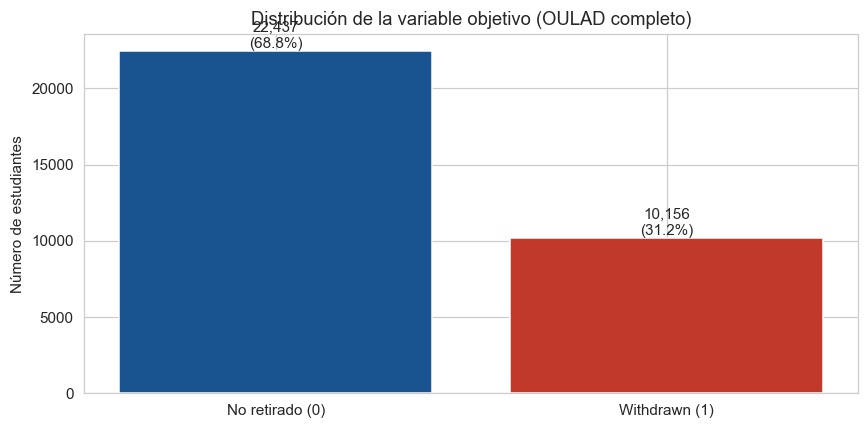

In [9]:
# Aquí visualizamos el balance de clases en la variable objetivo y guardamos la figura.
fig, ax = plt.subplots(figsize=(8, 4))
counts = y.value_counts().sort_index()
bars = ax.bar(['No retirado (0)', 'Withdrawn (1)'], counts.values,
              color=['#1A5490', '#C0392B'])
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 200,
            f'{value:,}\n({100*value/len(y):.1f}%)',
            ha='center', fontsize=10)
ax.set_title('Distribución de la variable objetivo (OULAD completo)')
ax.set_ylabel('Número de estudiantes')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_class_balance.png', dpi=140)
plt.show()

---
## Fase 2 — Entrenamiento y Evaluación de Modelos (OE2)

Entrena Random Forest, XGBoost y CatBoost mediante validación cruzada estratificada de 10 pliegues con `GridSearchCV` anidado de 3 pliegues internos. SMOTE se aplica dentro del pipeline `imblearn`, solo sobre el pliegue de entrenamiento.

> *Esta celda puede tardar entre 30 minutos y 4 horas según la potencia de cómputo y el tamaño de las grillas de hiperparámetros.*

In [10]:
# Con el preprocesamiento completo, ahora podemos ejecutar la comparación de modelos utilizando validación cruzada anidada.
from src.f2_modeling import ModelComparator

# Ejecutamos la comparación de modelos utilizando validación cruzada anidada, con 10 pliegues externos y 3 internos para la selección de hiperparámetros.
comparator = ModelComparator(n_outer_folds=10, n_inner_folds=3)

# La función run_all ejecuta la validación cruzada anidada para todos los modelos definidos en ModelComparator,
model_results = comparator.run_all(X, y)

# Construimos una tabla de comparación con los resultados de todos los modelos y la guardamos como CSV.
comparison = comparator.build_comparison_table(model_results)
comparison.to_csv(RESULTS_DIR / 'comparison_table.csv', index=False)
comparison

12:57:52 [INFO] F2_Modeling :: ======================================================================
12:57:52 [INFO] F2_Modeling :: MODELO RandomForest: Algoritmo más utilizado en la predicción de abandono según Andrade-Girón et al. (2023). Sirve como modelo de referencia.
12:57:52 [INFO] F2_Modeling :: ======================================================================
12:57:52 [INFO] F2_Modeling :: Iniciando entrenamiento de RandomForest …
13:07:45 [INFO] F2_Modeling :: RandomForest entrenado en 592.4 s — AUC-ROC = 0.9442 (±0.0051), Recall = 0.9110
13:07:45 [INFO] F2_Modeling :: ======================================================================
13:07:45 [INFO] F2_Modeling :: MODELO XGBoost: Algoritmo de mejor desempeño en Patel y Amin (2024) sobre el mismo conjunto OULAD (87 % de exactitud).
13:07:45 [INFO] F2_Modeling :: ======================================================================
13:07:45 [INFO] F2_Modeling :: Iniciando entrenamiento de XGBoost …
13:12:13 [INFO] F

,Modelo,AUC-ROC (media),AUC-ROC (desv.),Recall Withdrawn,F1 ponderado,Precisión Withdrawn,Tiempo (s)
2,CatBoost,0.9457,0.0050,0.8804,0.8715,0.7452,1602.4
1,XGBoost,0.9453,0.0050,0.8714,0.8708,0.7481,268.2
0,RandomForest,0.9442,0.0051,0.9110,0.8693,0.7276,592.4


### Comparación visual de métricas por modelo

In [11]:
# 
from catboost import CatBoostClassifier
import numpy as np

# Probamos que CatBoost acepta el parámetro allow_writing_files=False sin errores, lo que indica que la instalación es compatible con el fix.
X_test = np.random.rand(100, 5)
y_test = np.random.randint(0, 2, 100)

# Si CatBoost lanza un error relacionado con la escritura de archivos, esto indicaría que la instalación no es compatible con el fix.
clf = CatBoostClassifier(
    iterations=10,
    verbose=False,
    allow_writing_files=False,
)

# Si no se produce ningún error al ejecutar este código, significa que CatBoost acepta el parámetro allow_writing_files=False correctamente, lo que indica que tu instalación es compatible con el fix.
clf.fit(X_test, y_test)
print("✓ CatBoost acepta allow_writing_files=False correctamente.")
print("✓ Tu instalación es compatible con el fix.")

✓ CatBoost acepta allow_writing_files=False correctamente.
✓ Tu instalación es compatible con el fix.


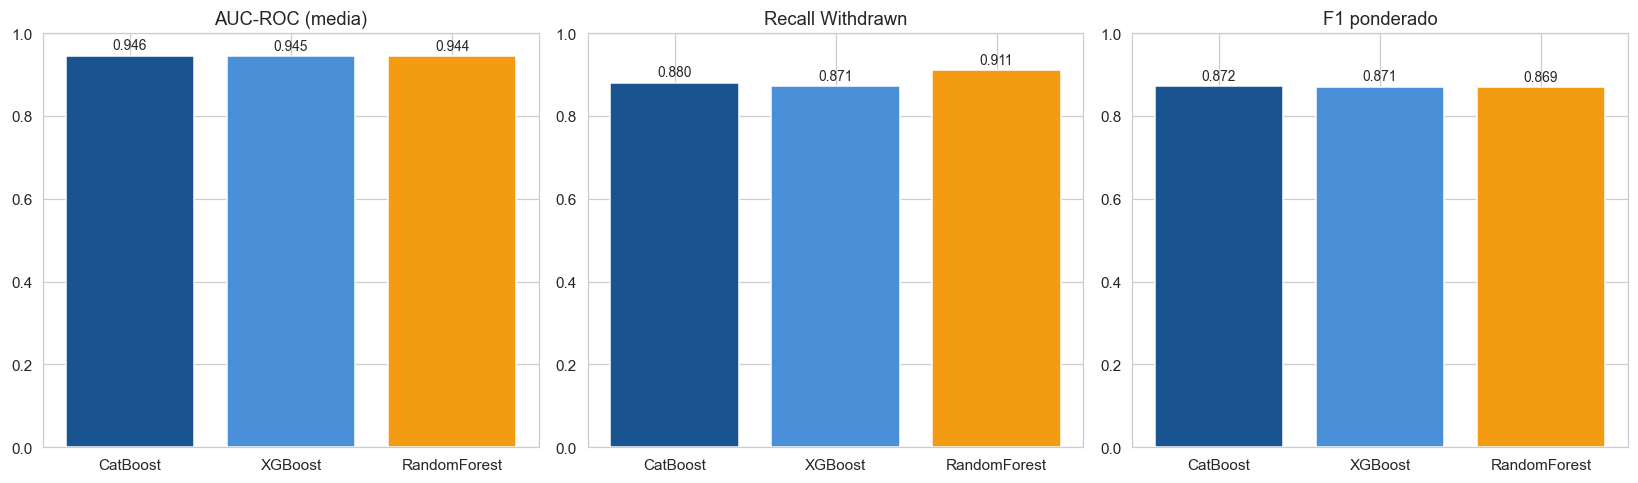

In [12]:
# Finalmente, visualizamos la comparación de modelos con gráficos de barras para las métricas AUC-ROC, 
# Recall Withdrawn y F1 ponderado, y guardamos la figura.
import matplotlib.pyplot as plt

metrics = ['AUC-ROC (media)', 'Recall Withdrawn', 'F1 ponderado']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, metrics):
    bars = ax.bar(comparison['Modelo'], comparison[metric],
                  color=['#1A5490', '#4A90D9', '#F39C12'])
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    for bar, value in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, value + 0.015,
                f'{value:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_model_comparison.png', dpi=140)
plt.show()

---
## Fase 3 — Análisis de Explicabilidad SHAP (OE3)

Aplica `TreeExplainer` a los tres modelos para generar:
- **Summary plots**: importancia global de las variables.
- **Dependence plots**: relación entre el valor de una variable y su contribución SHAP.
- **Waterfall plots**: diagnóstico individual para perfiles de riesgo alto, medio y bajo.

In [13]:
# Después de comparar los modelos, realizamos un análisis de SHAP para interpretar la importancia de las variables en cada modelo
# y guardamos los resultados.
from src.f3_shap_analysis import run_shap_analysis_all_models

shap_results = run_shap_analysis_all_models(
    trained_models=model_results,
    X=X, y=y,
    output_dir=RESULTS_DIR,
    sample_size=3000,
)
for name, art in shap_results.items():
    print(f'\n{name} — Top 10 variables:')
    print(art.global_importance.head(10).to_string())

13:40:39 [INFO] F3_SHAP :: Analizando SHAP de RandomForest …
14:01:59 [INFO] F3_SHAP :: Analizando SHAP de XGBoost …
14:02:03 [INFO] F3_SHAP :: Analizando SHAP de CatBoost …



RandomForest — Top 10 variables:
last_interaction_day         0.166463
num_assessments_submitted    0.098842
interaction_days             0.035726
total_clicks                 0.024604
studied_credits              0.014878
median_clicks_per_day        0.014622
clicks_quiz                  0.014190
clicks_resource              0.013949
clicks_oucontent             0.013556
std_score                    0.013111

XGBoost — Top 10 variables:
last_interaction_day                    2.954124
num_assessments_submitted               0.672824
studied_credits                         0.190252
region_Scotland                         0.133498
highest_education_Lower Than A Level    0.108285
region_Wales                            0.097289
region_North Western Region             0.092681
interaction_days                        0.090692
imd_band_10-20                          0.089423
first_interaction_day                   0.087435

CatBoost — Top 10 variables:
last_interaction_day                 

---
## Fase 4 — Análisis Estadístico de Consistencia (OE4)

Prueba de Kruskal-Wallis con corrección de Bonferroni sobre las distribuciones SHAP, para identificar predictores cuya contribución es estadísticamente consistente entre los tres algoritmos.

In [14]:
# Finalmente, realizamos un análisis de consistencia estadística de los valores SHAP para identificar predictores robustos y dependientes del algoritmo.
from src.f4_statistical_consistency import (
    SHAPConsistencyAnalyzer, summarize_consistency,
)

# Construimos un diccionario con los valores SHAP de cada modelo y los nombres de las variables para el análisis de consistencia.
shap_dict = {name: art.shap_values for name, art in shap_results.items()}
feature_names = next(iter(shap_results.values())).feature_names

# Ejecutamos el análisis de consistencia estadística utilizando SHAPConsistencyAnalyzer, que identifica predictores robustos y dependientes del algoritmo.
analyzer = SHAPConsistencyAnalyzer(alpha=0.05, top_n=20)
consistency = analyzer.analyze(shap_dict, feature_names)

print('Predictores robustos:')
for v in consistency.robust_predictors:
    print(f'  ✓ {v}')
print('\nDependientes del algoritmo:')
for v in consistency.algorithm_dependent:
    print(f'  ⚠ {v}')
print('\nResumen interpretativo:')
print(summarize_consistency(consistency))

14:02:45 [INFO] F4_Statistics :: Corrección de Bonferroni: alpha = 0.000625 (80 pruebas totales)


Predictores robustos:

Dependientes del algoritmo:
  ⚠ last_interaction_day
  ⚠ num_assessments_submitted
  ⚠ studied_credits
  ⚠ interaction_days
  ⚠ region_Scotland
  ⚠ first_interaction_day
  ⚠ highest_education_Lower Than A Level
  ⚠ gender_M
  ⚠ median_clicks_per_day
  ⚠ imd_band_10-20
  ⚠ region_Wales
  ⚠ imd_band_20-30%
  ⚠ clicks_quiz
  ⚠ imd_band_30-40%
  ⚠ region_North Western Region
  ⚠ imd_band_50-60%
  ⚠ clicks_url
  ⚠ mean_score
  ⚠ imd_band_40-50%
  ⚠ early_active_days

Resumen interpretativo:
Tras aplicar la prueba de Kruskal-Wallis con corrección de Bonferroni (α corregido = 0.00063) sobre las 20 variables de mayor importancia SHAP, 0 variables (0.0 %) presentan distribuciones equivalentes entre los tres algoritmos y se clasifican como predictores robustos: . Las 20 variables restantes presentan diferencias significativas entre al menos dos modelos, lo que indica que su poder predictivo depende parcialmente del algoritmo. La tabla de comparaciones pareadas Mann-Whitney

In [15]:
# A continuación, realizamos un análisis más detallado de la consistencia de los valores SHAP entre los modelos utilizando
# varias métricas estadísticas y visualizaciones. 
import numpy as np
import pandas as pd 
from itertools import combinations 
from scipy.stats import spearmanr

# ── 1. Matriz unificada de importancias ────────────────────────────────
all_vars = sorted(set().union(*[
    art.global_importance.index for art in shap_results.values()
]))
importance_matrix = pd.DataFrame(index=all_vars)
for name, art in shap_results.items():
    importance_matrix[name] = art.global_importance.reindex(all_vars, fill_value=0.0)

# ── 2. Correlación de Spearman por pares ───────────────────────────────
print("=" * 70)
print("CONSISTENCIA DE RANGOS — Correlación de Spearman entre algoritmos")
print("=" * 70)
spearman_results = []
for m1, m2 in combinations(importance_matrix.columns, 2):
    rho, p = spearmanr(importance_matrix[m1], importance_matrix[m2])
    spearman_results.append({"par": f"{m1} vs {m2}", "rho": rho, "p_value": p})
    print(f"  {m1:14s} ↔ {m2:14s}: ρ = {rho:.4f}   (p = {p:.2e})")

# ── 3. W de Kendall — concordancia simultánea de los tres modelos ──────
ranks = importance_matrix.rank(ascending=False)  # rangos por modelo
n_items, k_judges = ranks.shape
S = ((ranks.sum(axis=1) - k_judges * (n_items + 1) / 2) ** 2).sum()
W = 12 * S / (k_judges ** 2 * (n_items ** 3 - n_items))
print(f"\n  W de Kendall (3 modelos): W = {W:.4f}")
print(f"  Interpretación: 0 = sin acuerdo, 1 = acuerdo perfecto")

# ── 4. Jaccard sobre top-K ─────────────────────────────────────────────
def top_k_set(art, k):
    return set(art.global_importance.head(k).index)

print(f"\n{'=' * 70}")
print("ACUERDO EN LAS VARIABLES MÁS IMPORTANTES — Índice de Jaccard")
print("=" * 70)
for k in (5, 10, 20):
    sets = {name: top_k_set(art, k) for name, art in shap_results.items()}
    print(f"\n  Top-{k}:")
    for m1, m2 in combinations(sets, 2):
        inter = sets[m1] & sets[m2]
        union = sets[m1] | sets[m2]
        j = len(inter) / len(union)
        print(f"    {m1:14s} ↔ {m2:14s}: J = {j:.2f}   "
              f"({len(inter)} compartidas / {len(union)} unión)")
    # Intersección de los tres
    triple = sets["RandomForest"] & sets["XGBoost"] & sets["CatBoost"]
    print(f"  → Variables en top-{k} de los TRES modelos ({len(triple)}):")
    for v in sorted(triple):
        print(f"     • {v}")

# ── 5. Tabla de núcleo robusto (definición rank-based) ─────────────────
# Una variable es "robusta" si aparece en el top-10 de los TRES modelos
top10_all = set.intersection(*[top_k_set(art, 10) for art in shap_results.values()])
robust_table = importance_matrix.loc[sorted(top10_all)].copy()
robust_table["rank_RF"] = importance_matrix["RandomForest"].rank(ascending=False).astype(int)
robust_table["rank_XGB"] = importance_matrix["XGBoost"].rank(ascending=False).astype(int)
robust_table["rank_CB"] = importance_matrix["CatBoost"].rank(ascending=False).astype(int)
robust_table = robust_table.loc[sorted(top10_all)]
print(f"\n{'=' * 70}\nNÚCLEO ROBUSTO (top-10 en los tres modelos)\n{'=' * 70}")
print(robust_table)
robust_table.to_csv(RESULTS_DIR / "robust_predictors_rank_based.csv")

CONSISTENCIA DE RANGOS — Correlación de Spearman entre algoritmos
  RandomForest   ↔ XGBoost       : ρ = 0.5164   (p = 2.02e-04)
  RandomForest   ↔ CatBoost      : ρ = 0.7463   (p = 1.73e-09)
  XGBoost        ↔ CatBoost      : ρ = 0.8348   (p = 3.06e-13)

  W de Kendall (3 modelos): W = 0.7994
  Interpretación: 0 = sin acuerdo, 1 = acuerdo perfecto

ACUERDO EN LAS VARIABLES MÁS IMPORTANTES — Índice de Jaccard

  Top-5:
    RandomForest   ↔ XGBoost       : J = 0.43   (3 compartidas / 7 unión)
    RandomForest   ↔ CatBoost      : J = 0.67   (4 compartidas / 6 unión)
    XGBoost        ↔ CatBoost      : J = 0.43   (3 compartidas / 7 unión)
  → Variables en top-5 de los TRES modelos (3):
     • last_interaction_day
     • num_assessments_submitted
     • studied_credits

  Top-10:
    RandomForest   ↔ XGBoost       : J = 0.25   (4 compartidas / 16 unión)
    RandomForest   ↔ CatBoost      : J = 0.43   (6 compartidas / 14 unión)
    XGBoost        ↔ CatBoost      : J = 0.54   (7 compartidas

---
## Fase 5 — Formulación y Validación Pedagógica (OE5)

Traduce los hallazgos técnicos a tres perfiles de riesgo con recomendaciones accionables. Genera el cuestionario Likert que se distribuirá entre los tutores expertos para la validación cualitativa.

In [16]:
from src.f5_pedagogy import (
    get_baseline_risk_profiles, build_validation_questionnaire,
    classify_students_by_risk,
)

# Mejor modelo según AUC-ROC para la clasificación pedagógica
best_name = max(model_results, key=lambda n: model_results[n].cv_metrics['auc_roc_mean'])
best_model = model_results[best_name].best_estimator
print(f'Mejor modelo seleccionado para la fase pedagógica: {best_name}')

y_proba = best_model.predict_proba(X)[:, 1]
profiles = get_baseline_risk_profiles()
risk_labels = classify_students_by_risk(y_proba, profiles)

print('\nDistribución de estudiantes por nivel de riesgo:')
print(risk_labels.value_counts(normalize=True).round(3))

# Cuestionario para los tres tutores expertos
questionnaire = build_validation_questionnaire(profiles)
questionnaire.to_csv(RESULTS_DIR / 'likert_questionnaire.csv', index=False)
questionnaire.head(8)

Mejor modelo seleccionado para la fase pedagógica: CatBoost

Distribución de estudiantes por nivel de riesgo:
risk_level
bajo     0.637
alto     0.234
medio    0.129
Name: proportion, dtype: float64


,perfil_riesgo,dimension_Likert,descripcion_perfil,acciones_propuestas,puntuacion_1_a_5,observacion_cualitativa
0,alto,comprensibilidad,Total de clics en el LMS en el cuartil inferio...,Contacto sincrónico individualizado del tutor ...,,
1,alto,aplicabilidad,Total de clics en el LMS en el cuartil inferio...,Contacto sincrónico individualizado del tutor ...,,
2,alto,pertinencia,Total de clics en el LMS en el cuartil inferio...,Contacto sincrónico individualizado del tutor ...,,
3,alto,novedad,Total de clics en el LMS en el cuartil inferio...,Contacto sincrónico individualizado del tutor ...,,
4,alto,factibilidad,Total de clics en el LMS en el cuartil inferio...,Contacto sincrónico individualizado del tutor ...,,
5,alto,impacto_percibido,Total de clics en el LMS en el cuartil inferio...,Contacto sincrónico individualizado del tutor ...,,
6,medio,comprensibilidad,Interacción LMS irregular: días con alta activ...,Mensaje proactivo del tutor mediante el sistem...,,
7,medio,aplicabilidad,Interacción LMS irregular: días con alta activ...,Mensaje proactivo del tutor mediante el sistem...,,


---
## Exportación de los datos consumidos por el dashboard

Genera un único `dashboard_data.json` que el dashboard de Streamlit lee para mostrar todos los resultados en tiempo real.

In [17]:
from main_pipeline import Pipeline

pipeline = Pipeline(
    data_path=DATA_PATH,
    output_dir=RESULTS_DIR,
    shap_sample_size=3000,
)
pipeline.export_dashboard_data(
    artifacts, model_results, shap_results, consistency,
    profiles, risk_labels.value_counts(normalize=True).round(3).to_dict(),
)
print('\nPipeline completado. Datos del dashboard exportados.')
print('\nLanza el dashboard con:')
print('    streamlit run dashboard/dashboard.py -- --results-dir ./results')

14:03:18 [INFO] MainPipeline :: Datos del dashboard exportados a d:\WORK_SPACE\VSCode\TFM\results\dashboard_data.json



Pipeline completado. Datos del dashboard exportados.

Lanza el dashboard con:
    streamlit run dashboard/dashboard.py -- --results-dir ./results


---
## Síntesis interpretativa

Esta última celda construye el resumen final que se incorporará al Capítulo 5 (Resultados) y al Capítulo 6 (Discusión) de la memoria. Recoge las cifras clave de cada fase y las articula en prosa académica.

In [18]:
summary_text = f'''
RESULTADOS DEL PILOTO EXPERIMENTAL
==================================

F1 — Preprocesamiento
  Estudiantes totales : {artifacts.class_balance['n_total']:,}
  Tasa de abandono    : {artifacts.class_balance['withdrawn_pct']} %
  Variables construidas: {len(artifacts.feature_names)}

F2 — Comparativa de modelos (10-fold Stratified CV con SMOTE in-fold)
{comparison.to_string(index=False)}
  Mejor modelo: {best_name}

F3 — Top 5 predictores SHAP del mejor modelo ({best_name})
{shap_results[best_name].global_importance.head(5).to_string()}

F4 — Consistencia entre algoritmos (Kruskal-Wallis + Bonferroni)
  α corregido         : {consistency.alpha_bonferroni:.5f}
  Predictores robustos: {len(consistency.robust_predictors)}
  Algoritmo-dependientes: {len(consistency.algorithm_dependent)}

F5 — Distribución de riesgo (mejor modelo aplicado al dataset completo)
  Alto  : {risk_labels.value_counts(normalize=True).get("alto", 0):.1%}
  Medio : {risk_labels.value_counts(normalize=True).get("medio", 0):.1%}
  Bajo  : {risk_labels.value_counts(normalize=True).get("bajo", 0):.1%}
'''
print(summary_text)

with open(RESULTS_DIR / 'final_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)


RESULTADOS DEL PILOTO EXPERIMENTAL

F1 — Preprocesamiento
  Estudiantes totales : 32,593
  Tasa de abandono    : 31.16 %
  Variables construidas: 47

F2 — Comparativa de modelos (10-fold Stratified CV con SMOTE in-fold)
      Modelo  AUC-ROC (media)  AUC-ROC (desv.)  Recall Withdrawn  F1 ponderado  Precisión Withdrawn  Tiempo (s)
    CatBoost           0.9457           0.0050            0.8804        0.8715               0.7452      1602.4
     XGBoost           0.9453           0.0050            0.8714        0.8708               0.7481       268.2
RandomForest           0.9442           0.0051            0.9110        0.8693               0.7276       592.4
  Mejor modelo: CatBoost

F3 — Top 5 predictores SHAP del mejor modelo (CatBoost)
last_interaction_day         2.073047
num_assessments_submitted    0.956191
studied_credits              0.252358
interaction_days             0.166104
first_interaction_day        0.160095

F4 — Consistencia entre algoritmos (Kruskal-Wallis + Bonfe